#### UAV Autonomy Summer Camp 2026: Abto Software

---

# <center> Домашнє завдання №1 <center>

#### виконав Горбатюк Данило

<br>

> Необхідно розробити програму на мові Python з використанням бібліотеки OpenCV для автоматичного підрахунку кількості монет на фотографії з білим фоном.

<br>

! Монети можуть бути розміщені як окремо, так і поряд або ж одна на одній, закриваючи деяку частину одна одної.

<i> \* для прикладу було взято фото із Classroom

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

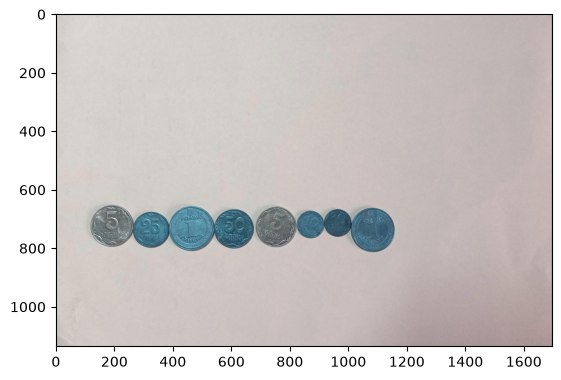

In [160]:
image = cv2.imread("coins.jpeg")

plt.imshow(image)

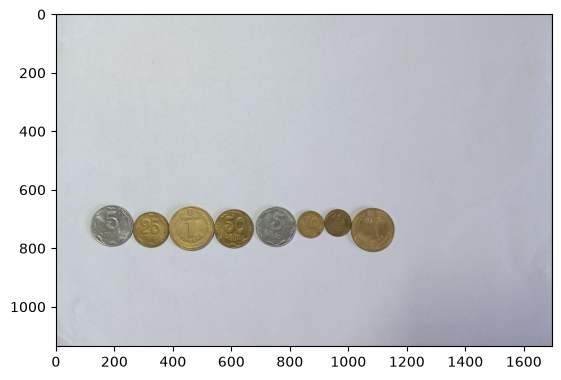

In [146]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [147]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

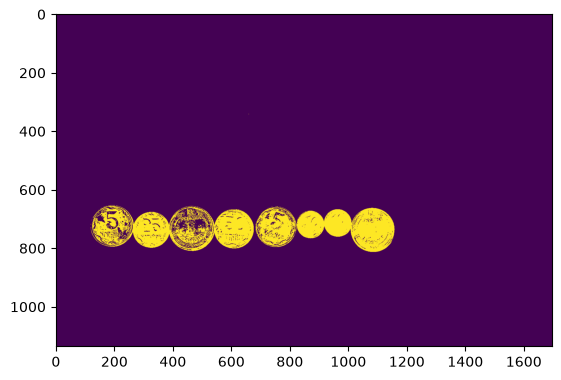

In [148]:
# підхід який ми використали на занятті
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
plt.imshow(binary)

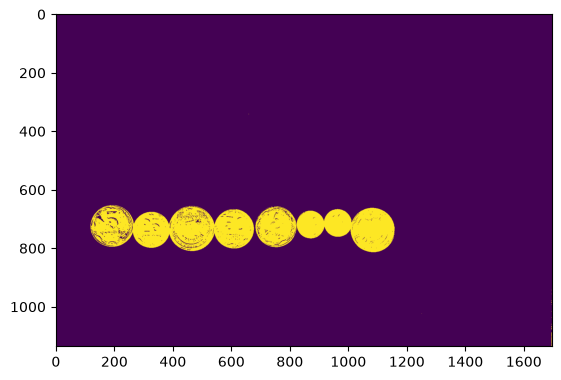

In [149]:
# підхід із використанням методу Оцу (поділ на чіткіші кластери по розподілу)
ret, otsu_binary = cv2.threshold(gray,
                             0, 255,
                             cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(otsu_binary)

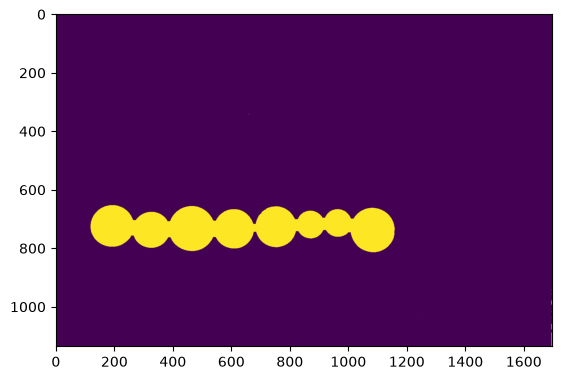

In [153]:
kernel = np.ones((5,5),np.uint8)

closing = cv2.morphologyEx(otsu_binary, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.imshow(closing)

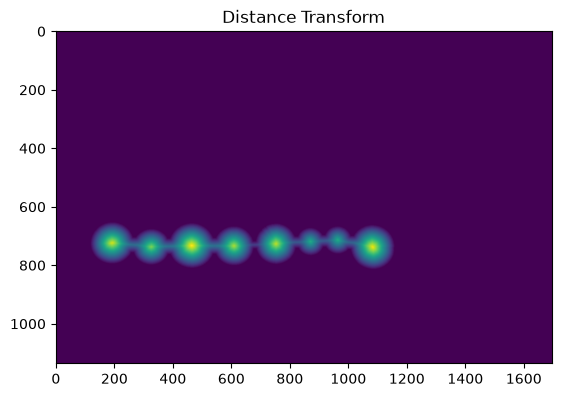

In [154]:
dist = cv2.distanceTransform(closing, cv2.DIST_L2, 5)
plt.title('Distance Transform')
plt.imshow(dist)

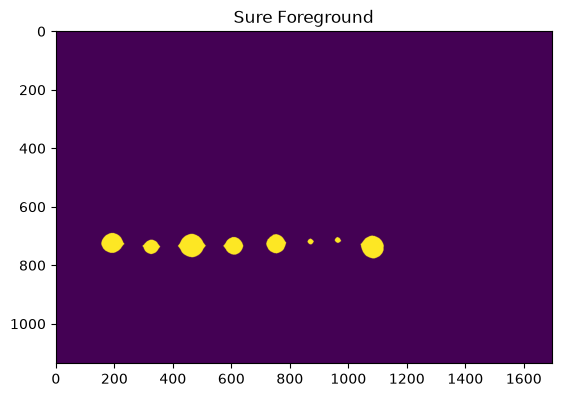

In [155]:
ret, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)
plt.title('Sure Foreground')
plt.imshow(sure_fg)

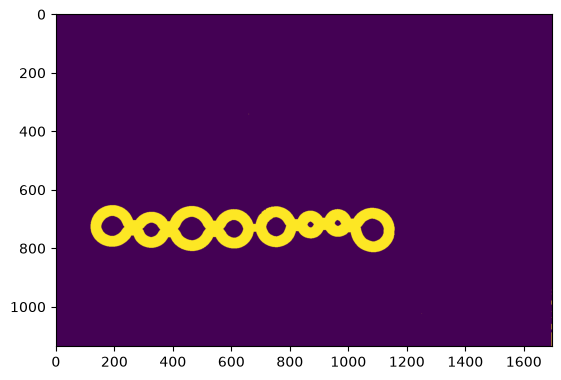

In [156]:
# unknown area
unknown = cv2.subtract(closing, sure_fg)
plt.imshow(unknown)

In [157]:
ret, markers = cv2.connectedComponents(sure_fg)

print(f"Кількість монет: {ret - 1}")

Кількість монет: 8


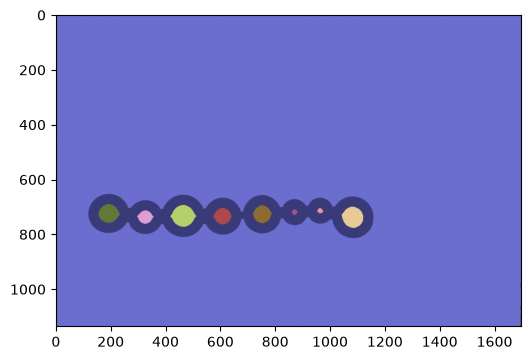

In [158]:
markers += 1
markers[unknown == 255] = 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(markers, cmap="tab20b")
plt.show()

In [159]:
unique_labels = np.unique(markers)
num_coins = len(unique_labels[(unique_labels != 1) & (unique_labels != -1) & (unique_labels != 0)])

print(f"Кількість монет: {num_coins}")

Кількість монет: 8


---

## Використані джерела
1. https://www.geeksforgeeks.org/computer-vision/image-segmentation-with-watershed-algorithm-opencv-python/